# Pesquisa: Gêmeo Digital x Unity WebGL
## Mineração, Enriquecimento e Análise de Repositórios GitHub

> **Objetivo:** Coletar repositórios GitHub relacionados a Digital Twin, Unity, WebGL e tecnologias correlatas,
> enriquecer com READMEs e resultados obtidos através da extração de dados de artigos pelo NotebookLM, afim de extrair stacks e gerar visualizações analíticas.

---
**Etapas do pipeline:**
1. Coleta das abas da planilha Google Sheets via gspread
2. Limpeza, remoção de dupliacatas e filtragem por estrelas (≥ 5)
3. Enriquecimento com owner e repo para captura do README via GitHub API
4. Normalização e classificação de tecnologias
5. Scoring de relevância
6. Geração de stacks tecnológicas
7. Visualizações gráficas por categoria expandida

**Categorias detectadas (baseadas nos artigos da revisão):**
`engine_visualizacao` · `plataforma_execucao` · `tecnologia_web` · `linguagem_backend`
`arquitetura` · `protocolo_frontend` · `protocolo_sensores` · `banco_dados`
`tipo_dados` · `plataforma_dt`

disclaimer: É válido mencionar que como estmos trabalhando com dados não numéricos, a medida em que enriquecemos nosso dicionário de palavras, podemos obter resultados mais precisos.

> Abaixo descrevo o pipeline de forma executável, cada seção é antecedida por um bloco de texto com título da seção e objetivo logo abaixo.

### Seção 0: mineração de repositórios do github através do App Script
> Coletar dados para a análise

Nesta fase foi utilizado o Google Apps Script integrado a planilha "extracao_repositorios".

O script consome a API de pesquisa do GitHub e busca termos específicos como:
- Unity
- WebGL
- Digital Twin ou Gemeo Digital

Essas palavras foram cruzadas com linguagens de programação e plugins como:
- Java
- C# (.NET/dotnet)
- Python
- Jslib
- Node.js

Também foi realizado o cruzamento entre os termos: Digital Twin e OpenSource

Os resultados foram coletados em diferentes abas da planilha e posteriormente foram reunidos na na aba "dados_total".

Abaixo está o script que automatizou a coleta e inseriu diretamente na planilha do sheets.

<pre>
function buscarRepositoriosGitHub() {
  var url = "https://api.github.com/search/repositories?q=unity+.net&per_page=50&sort=stars";
  
  var resposta = UrlFetchApp.fetch(url);
  var json = JSON.parse(resposta.getContentText());
  var repositorios = json.items;
  
  var folha = SpreadsheetApp.getActiveSpreadsheet().getActiveSheet();
  
  folha.clear();
  folha.appendRow(["Nome do Repositório", "URL", "Estrelas", "Linguagem", "Descrição"]);

  folha.getRange("A1:E1").setFontWeight("bold");
  
  for (var i = 0; i < repositorios.length; i++) {
    var repo = repositorios[i];
    
    folha.appendRow([
      repo.name,
      repo.html_url,
      repo.stargazers_count,
      repo.language || "Não especificada",
      repo.description || "Sem descrição"
    ]);
  }
}
</pre>

Após a mineração, notou-se que o campo linguagem não poderia ser considerado para fins de análise concreta.


## Seção 1: Instalação de dependencias, importação de bibliotecas e token via secrets
> Garantir que todas as bibliotecas necessárias estejam disponíveis no colab e o token possa ser utilizado


In [1]:
# instalando todas as dependencias para analise de dados com dataframe, geralção de gráficos e visualização de processos

!pip install pandas matplotlib wordcloud tqdm google-generativeai openpyxl gspread --quiet


In [2]:
# carregando todos os imports e capturando tokens salvos em secrets

import pandas as pd
import requests
import re
import time
import unicodedata
import numpy as np
from tqdm import tqdm
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from google.colab import userdata, auth
import gspread
from google.auth import default
from wordcloud import WordCloud

# nessa etapa deve ser criada uma chave api na sua conta e adicionada no ícone de chave do lado esquerdo, deixando a opcao de "acesso ao notebook" marcada
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')


## Seção 2: Conexão com Google Drive e autenticação
> Montar o Drive, autenticar no Google Sheets e consolidar todas as abas da planilha de extração em um dataframe


In [3]:
# montando drive para ser acessado

from google.colab import drive
drive.mount('/content/drive')

#autenticando o acesso para abertura de planilhas do gspread

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

#substituir o caminho após /content/drive/MyDrive de onde está localizada a planilha no seu google drive

path_project = '/content/drive/MyDrive/pesquisa_gemeo_digital_web/extracao_repositorios'

#configurando caminho de saida para os arquivos q serao gerados e salvos no drive - substituir pelo caminho da pasta no seu drive
PATH_OUT = '/content/drive/MyDrive/pesquisa_gemeo_digital_web/'


Mounted at /content/drive


In [4]:
# unificando todas as abas da planilha em um único dataframe consolidado (exceto dados_total e dados_selecionados)

#abrindo a planilha
planilha = gc.open('extracao_repositorios')

abas_nomes = [
    'keyOpenSource+DigitalTwin', 'keyPythonnet+unity', 'key.NET+unity',
    'key.NET+webgl', 'keyJSlib', 'keyJSlib+webgl', 'keydigital-twin',
    'keyDotnet', 'keyCsharp', 'keyNode.js', 'keyC#', 'keyJava', 'keyPython',
    'keyDigitalTwin+architecture', 'ArrayKeys', 'KeyDigitalTwin+Unity', 'keyDigitalTwin+Web',
]

# percorrendo abas_nomes e adicionando a lista_dfs
lista_dfs = []
for nome in abas_nomes:
    dados  = planilha.worksheet(nome).get_all_values()
    df_tmp = pd.DataFrame(dados[1:], columns=dados[0])
    lista_dfs.append(df_tmp)

#concatenando e visualizando a quantidade de registros do novo dataframe chamado df_consolidado
df_consolidado = pd.concat(lista_dfs, ignore_index=True)
print(f'Total bruto: {len(df_consolidado)} registros')


Total bruto: 473 registros


## Seção 3: Limpeza e Filtragem
> Remover duplicatas utilizando a coluna URL como chave primária, excluir a coluna Linguagem (não confiável via endpoint de busca),
> converter Estrelas para numérico e filtrar repositórios com menos de 5 estrelas.
>
> Obs: A coluna `Linguagem` da API retorna apenas a linguagem primária do repositório por isso não será utilizada na análise
>


In [5]:
# removendo duplicatas com base na URL

df_consolidado = df_consolidado.drop_duplicates(subset='URL')
df_consolidado.reset_index(drop=True, inplace=True)
print(f'Total registros após a remoção de duplicadas: {len(df_consolidado)}')

# removendo a coluna Linguagem
df_consolidado.drop(columns=['Linguagem'], inplace=True, errors='ignore')


Total registros após a remoção de duplicadas: 417


In [6]:
# convertendo a coluna Estrelas para numerico do tipo int
df_consolidado['Estrelas'] = pd.to_numeric(
    df_consolidado['Estrelas'].astype(str).str.replace('.', '', regex=False),
    errors='coerce'
).fillna(0).astype(int)

# ordenando pela coluna de estrelas de forma decrescente
df_consolidado.sort_values(by='Estrelas', ascending=False, inplace=True)

# filtrando apenas repositorios com 5 ou mais estrelas
df_consolidado = df_consolidado[df_consolidado['Estrelas'] >= 5].copy()
df_consolidado.reset_index(drop=True, inplace=True)

print(f'Total após o filtro de estrelas: {len(df_consolidado)}')
df_consolidado.head()


Total após o filtro de estrelas: 253


,Nome do Repositório,URL,Estrelas,Descrição
0,ILSpy,https://github.com/icsharpcode/ILSpy,24732,.NET Decompiler with support for PDB generatio...
1,Some-Many-Books,https://github.com/Dujltqzv/Some-Many-Books,18419,个人收藏书籍列表 ...
2,xLua,https://github.com/Tencent/xLua,10048,xLua is a lua programming solution for C# ( U...
3,MultiplayerNetworkingResources,https://github.com/0xFA11/MultiplayerNetworkin...,8413,A curated list of Multiplayer Game Network Pro...
4,MessagePack-CSharp,https://github.com/MessagePack-CSharp/MessageP...,6621,Extremely Fast MessagePack Serializer for C#(....


## Seção 4: Extração de Owner e Repo da URL
> Separar owner e nome do repositório da URL para utilizar na API de coleta dos READMEs


In [7]:
# extracao de owner e repo via regex

df_consolidado[['Owner', 'Repo']] = df_consolidado['URL'].str.extract(
    r'github\.com/([^/]+)/([^/]+)'
)

df_consolidado['Repo'] = df_consolidado['Repo'].str.replace('.git', '', regex=False)

ok = df_consolidado[['Owner','Repo']].notna().all(axis=1).sum()


print(f'Owner/Repo extraídos para {ok}/{len(df_consolidado)} repositórios')

#visualizando o dataframe com as novas colunas
df_consolidado[['Nome do Repositório', 'URL', 'Owner', 'Repo']].head()


Owner/Repo extraídos para 253/253 repositórios


,Nome do Repositório,URL,Owner,Repo
0,ILSpy,https://github.com/icsharpcode/ILSpy,icsharpcode,ILSpy
1,Some-Many-Books,https://github.com/Dujltqzv/Some-Many-Books,Dujltqzv,Some-Many-Books
2,xLua,https://github.com/Tencent/xLua,Tencent,xLua
3,MultiplayerNetworkingResources,https://github.com/0xFA11/MultiplayerNetworkin...,0xFA11,MultiplayerNetworkingResources
4,MessagePack-CSharp,https://github.com/MessagePack-CSharp/MessageP...,MessagePack-CSharp,MessagePack-CSharp


## Seção 5: Coleta de READMEs via GitHub API
> Enriquecer cada repositório com o conteúdo do README.
> O endpoint `/repos/{owner}/{repo}/readme` com `Accept: application/vnd.github.v3.raw`
> retorna o texto bruto diretamente, sem necessidade de decodificar base64.
>
> Rate limit: `time.sleep(0.25)` entre requisições para evitar bloqueios. Com token autenticado de 5.000 requisições por hora.


In [8]:
# funcoes para captura dos readmes passaando owner e repo como parametros
# tenta obter_readme, se nao responde exception

def obter_readme(owner, repo):
    url     = f'https://api.github.com/repos/{owner}/{repo}/readme'
    headers = {
        'Authorization': f'Bearer {GITHUB_TOKEN}',
        'Accept': 'application/vnd.github.v3.raw'
    }
    try:
        r = requests.get(url, headers=headers, timeout=10)
        return r.text if r.status_code == 200 else None
    except Exception:
        return None

# extracao com timesleep de 0.25 para evitar limite de requisicoes
def capturar_readme(row):
    print(f'Extraindo: {row["Owner"]}/{row["Repo"]}')
    time.sleep(0.25)
    return obter_readme(row['Owner'], row['Repo'])

# criando um novo dataframe a partir do df_consolidado, agora chamado de df_enriquecida
df_enriquecida = df_consolidado.copy()
df_enriquecida['readme'] = df_enriquecida.apply(capturar_readme, axis=1)

taxa = df_enriquecida['readme'].notna().sum()
print(f'\nTotal de readmes coletados: {taxa}/{len(df_enriquecida)}')


Extraindo: icsharpcode/ILSpy
Extraindo: Dujltqzv/Some-Many-Books
Extraindo: Tencent/xLua
Extraindo: 0xFA11/MultiplayerNetworkingResources
Extraindo: MessagePack-CSharp/MessagePack-CSharp
Extraindo: pardeike/Harmony
Extraindo: Cysharp/ZLinq
Extraindo: Cysharp/MagicOnion
Extraindo: magcius/noclip.website
Extraindo: rlabrecque/Steamworks.NET
Extraindo: Cysharp/ZString
Extraindo: nicolesaidy/awesome-web-design
Extraindo: neuecc/ZeroFormatter
Extraindo: neuecc/Utf8Json
Extraindo: Unity-Technologies/com.unity.netcode.gameobjects
Extraindo: TeamSirenix/odin-serializer
Extraindo: FirstGearGames/FishNet
Extraindo: Cysharp/MasterMemory
Extraindo: Cysharp/MessagePipe
Extraindo: gridsound/daw
Extraindo: videolan/libvlcsharp
Extraindo: Cysharp/Ulid
Extraindo: BeardedManStudios/ForgeNetworkingRemastered
Extraindo: andremichelle/openDAW
Extraindo: amirgamil/apollo
Extraindo: KosmosisDire/obsidian-webpage-export
Extraindo: De-Panther/unity-webxr-export
Extraindo: fo-dicom/fo-dicom
Extraindo: psygames/

## Seção 6: Preparação e normalização do texto
> Combinar as colunas de descrição + readme em `texto`, normalizar para lowercase,
> remover acentos e padronizar aliases de tecnologias, isso facilitará a busca de palavras.


In [9]:
# combinando as colunas descricao e readme na coluna texto padronizada e sem acentuação
# os repositorios que não foram capturados os readmes terão apenas a decricao na coluna texto

#criando um dataframe df a partir de df_enriquecida para não alterar os dados originais

df = df_enriquecida.copy()
df['Descrição'] = df['Descrição'].fillna('')
df['readme'] = df['readme'].fillna('')
df['texto'] = df['Descrição'].str.lower() + ' ' + df['readme'].str.lower()

print(f'Total de repositórios: {len(df)}')


Total de repositórios: 253


In [10]:
# mapeando aliases para termos canonicos via regex com word boundary para evitar substituicoes parciais
# a normalizacao semantica foi enriquecida com termos encontrados na extracao dos artigos científicos

normalizacao = {
    # linguagens backend
    'javascript' : ['node.js', 'nodejs', 'node js'],
    'typescript' : ['ts', 'typescript'],
    'python' : ['python', 'django', 'flask', 'fastapi'],
    'java' : ['spring boot', 'spring', 'java'],
    'c#' : ['csharp', 'c-sharp', 'dotnet', '.net', 'asp.net'],
    'c++' : ['cpp', 'c++'],
    'go' : ['golang', 'go lang', 'go language'],
    'rust' : ['rust'],
    'matlab' : ['matlab', 'simulink'],

    # engines e frameworks de visualizacao 3d na web
    'three.js' : ['threejs', 'three js'],
    'unity' : ['unity3d', 'unity webgl', 'unity'],
    'unreal' : ['unreal engine', 'unreal'],
    'babylon.js' : ['babylonjs', 'babylon js', 'babylon'],
    'cesium' : ['cesiumjs', 'cesium js'],

    # webgl e webxr / alguns repositorios DT sao para VR
    'webgl' : ['web-gl', 'webgl2', 'web gl', 'WebGL'],
    'webxr' : ['webxr', 'web-vr', 'webvr', 'web-ar'],

    # protocolos frontend (artigos: WebSocket, Socket.IO)
    'websocket'   : ['web socket', 'websockets', 'socket.io'],

    # protocolos de sensores (artigos: OPC-UA, MQTT, Modbus-RTU)
    'opc-ua' : ['opc ua', 'opcua', 'opc unified architecture'],
    'mqtt' : ['mqtt'],
    'modbus' : ['modbus-rtu', 'modbus rtu', 'modbus tcp', 'modbus'],
    'coap'  : ['coap'],

    # protocolos gerais
    'grpc' : ['grpc', 'g rpc'],
    'http/rest' : ['rest api', 'restful', 'http rest'],

    # arquiteturas (artigos: B/S 6 camadas, CPS, 5C, GADIT)
    'browser/server': ['b/s architecture', 'browser server', 'browser/server'],
    'microservices' : ['microservice', 'micro service', 'microservices'],
    'cps' : ['cyber physical', 'cyber-physical', 'cps'],
    'event-driven' : ['event driven', 'event-driven', 'event based', 'event-based architecture','eda architecture'],
    'gadit': [ 'gadit', 'gadit architecture'],
    'monolithic': ['monolithic','monolith','monolithic architecture','monolith architecture'],

    # bancos de dados
    'sqlite' : ['sqlite'],
    'sql server' : ['sql server', 'mssql', 'microsoft sql'],
    'influxdb' : ['influxdb', 'influx db'],
    'mongodb' : ['mongodb', 'mongo db'],
    'postgresql' : ['postgresql', 'postgres'],
    'redis': ['redis'],

    # Plataformas DT (artigos: Eclipse Ditto, PTC ThingWorx, Twinbase)
    'eclipse ditto' : ['eclipse ditto'],
    'thingworx' : ['thingworx', 'ptc thingworx'],
    'azure iot' : ['azure iot', 'microsoft azure iot'],
    'aws iot' : ['aws iot', 'amazon iot'],
    'siemens mindsphere': ['mindsphere'],

    # conceitos
    'digital twin': ['digital-twin', 'digitaltwin', 'digital twins', 'gemeo digital'],
    'industry': ['industry','industry 4.0', 'industrie 4.0', 'i4.0'],
}

def remover_acentos(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

def limpar_texto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = remover_acentos(texto)
    texto = re.sub(r'#|\*|\[|\]|\(|\)', ' ', texto)
    texto = re.sub(r'[^a-z0-9\s\+#\.-/]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def normalizar_tecnologias(texto):
    if not isinstance(texto, str):
        return ''
    for canonical, aliases in normalizacao.items():
        for alias in aliases:
            texto = re.sub(r'\b' + re.escape(alias) + r'\b', canonical, texto)
    return texto

df['texto'] = df['texto'].apply(limpar_texto)
df['texto'] = df['texto'].apply(normalizar_tecnologias)

print('Texto normalizado e padronizado')


Texto normalizado e padronizado


## Seção: Desambiguação: C#, Go e JavaScript
> Essa seção busca evitar falsos positivos em linguagens com nomes ambíguos que podem ser contabilizados erroneamente.

> - go: aparece em contextos comuns do inglês. Exige sinais mais fortes como golang ou go language.
> - c#: diferencia Unity (scripts MonoBehaviour) vs .NET Backend (APIs, microserviços).
> - js: diferencia uso no frontend vs backend com Node.js.


In [11]:
# funcoes para desambiguação

def detectar_go(texto):
    palavras_fortes = [
        'golang', 'go.mod', 'go.sum', 'goroutine',
        'gin-gonic', 'go build', 'go run', 'go get', 'package main'
    ]
    blacklist = ['go to', 'go back', 'go ahead', "let's go", 'going to']
    if any(b in texto for b in blacklist):
        return False
    return any(p in texto for p in palavras_fortes)

def classificar_csharp_contexto(texto):
    if any(s in texto for s in ['unity', 'unity3d', 'monobehaviour', 'gameobject', 'unityengine', 'prefab']):
        return 'C# (Unity)'
    if any(s in texto for s in ['asp.net', '.net', 'entity framework']):
        return 'C# (.NET Backend)'
    return 'C#'

def classificar_javascript_contexto(texto):
    if 'node' in texto or 'express' in texto or 'node.js' in texto:
        return 'JavaScript (Node.js)'
    if 'react' in texto or 'vue' in texto or 'angular' in texto:
        return 'JavaScript (Frontend)'
    return 'JavaScript'

print('funções de desambiguação prontas')


funções de desambiguação prontas


## Seção 8: Extração de Tecnologias e Scoring de Relevância
> Detectar tecnologias via coluna texto (desc + readme)
> e calcular score de relevância para a pesquisa sobre Digital Twins.
>
> **Correção aplicada:** linguagens backend agora são detectadas por keywords no texto
> (ex: `python`, `django`, `node.js`, `java`, `c#`), resolvendo o problema de detecção zero
> causado pela coluna `Linguagem` sempre vazia.


In [12]:
# termos para extracao extracao via coluna de texto adicionados a uma lista de techs

def extrair_tecnologias(texto):
    techs = set()

    # Engines de visualização
    if 'three.js' in texto: techs.add('Three.js')
    if 'unity'  in texto: techs.add('Unity')
    if 'unreal' in texto: techs.add('Unreal Engine')
    if 'babylon.js' in texto: techs.add('Babylon.js')
    if 'cesium' in texto: techs.add('Cesium')
    if 'microservices' in texto: techs.add('Microservices')
    if 'monolithic' in texto: techs.add('Monolithic Architecture')
    if 'event-driven' in texto: techs.add('Event-Driven Architecture')
    if 'gadit' in texto: techs.add('GADIT Architecture')


    # Render / plataforma web
    if 'webgl'  in texto: techs.add('WebGL')
    if 'webxr'  in texto: techs.add('WebXR')
    if 'react'  in texto: techs.add('React')
    if 'vue'    in texto: techs.add('Vue.js')
    if 'angular' in texto: techs.add('Angular')
    if 'html5'  in texto: techs.add('HTML5')
    if 'express' in texto: techs.add('Express.js')

    # Protocolos frontend
    if 'websocket' in texto: techs.add('WebSocket')
    if 'socket.io' in texto: techs.add('Socket.IO')
    if 'http/rest' in texto or 'rest' in texto: techs.add('HTTP/REST')
    if 'grpc'  in texto: techs.add('gRPC')
    if 'graphql' in texto: techs.add('GraphQL')

    # Protocolos de sensores / IoT
    if 'mqtt' in texto: techs.add('MQTT')
    if 'opc-ua' in texto: techs.add('OPC-UA')
    if 'modbus' in texto: techs.add('Modbus')
    if 'coap' in texto: techs.add('CoAP')
    if 'amqp' in texto: techs.add('AMQP')
    if 'kafka' in texto: techs.add('Kafka')

    # Linguagens
    if 'python' in texto or 'django' in texto or 'flask' in texto:
        techs.add('Python')
    if 'javascript' in texto or 'node.js' in texto or 'node' in texto:
        techs.add(classificar_javascript_contexto(texto))
    if 'typescript' in texto:
        techs.add('TypeScript')
    if 'c#' in texto:
        techs.add(classificar_csharp_contexto(texto))
    if 'java' in texto and 'javascript' not in texto:
        techs.add('Java')
    if 'golang' in texto or 'go.mod' in texto:
        techs.add('Go')
    if 'rust' in texto:
        techs.add('Rust')
    if 'c++' in texto or 'cpp' in texto:
        techs.add('C++')
    if 'matlab' in texto:
        techs.add('MATLAB')
    if 'php' in texto:
        techs.add('PHP')

    # Bancos de dados
    if 'sqlite' in texto: techs.add('SQLite')
    if 'sql server' in texto or 'mssql' in texto: techs.add('SQL Server')
    if 'postgresql' in texto: techs.add('PostgreSQL')
    if 'mongodb' in texto: techs.add('MongoDB')
    if 'influxdb' in texto: techs.add('InfluxDB')
    if 'redis' in texto: techs.add('Redis')
    if 'mysql' in texto: techs.add('MySQL')
    if 'timescaledb' in texto: techs.add('TimescaleDB')

    # Plataformas
    if 'eclipse ditto' in texto: techs.add('Eclipse Ditto')
    if 'thingworx' in texto: techs.add('PTC ThingWorx')
    if 'azure iot' in texto: techs.add('Azure IoT')
    if 'aws iot' in texto: techs.add('AWS IoT')
    if 'mindsphere' in texto: techs.add('Siemens MindSphere')
    if 'twinbase'  in texto: techs.add('Twinbase')
    if 'fiware' in texto: techs.add('FIWARE')

    # Conceitos / arquitetura
    if 'iot' in texto: techs.add('IoT')
    if 'digital twin' in texto: techs.add('Digital Twin')
    if 'microservice' in texto: techs.add('Microservices')
    if 'industry' in texto: techs.add('Industry')
    if 'robot' in texto or 'ros' in texto: techs.add('Robótica/ROS')

    return list(techs)

print('funcao extrair_tecnologias pronta')


funcao extrair_tecnologias pronta


In [13]:
# sistema de score e classificacao por relevancia
# +3 digital twin
# +2 unity / webgl / unreal / three.js (considerando outras engines que podem aparecer)
# +2 mqtt / opc-ua / modbus / coap
# +1 iot
# +1 simulation / industry 4.0 / eclipse ditto / thingworx
# ALTA >=5 - MÉDIA >=4 - BAIXA >=1 - NÃO RELEVANTE

def calcular_score(texto):
    score = 0
    if 'digital twin' in texto: score += 3
    if any(t in texto for t in ['unity', 'webgl', 'unreal', 'three.js']): score += 2
    if any(t in texto for t in ['mqtt', 'opc-ua', 'modbus', 'coap']): score += 2
    if 'iot' in texto: score += 1
    if any(t in texto for t in ['simulation', 'industry', 'eclipse ditto', 'thingworx']): score += 1
    return score

def classificar_relevancia(score):
    if score >= 5: return 'ALTA'
    elif score >= 3: return 'MÉDIA'
    elif score >= 1: return 'BAIXA'
    return 'NÃO RELEVANTE'

df['score']       = df['texto'].apply(calcular_score)
df['relevancia']  = df['score'].apply(classificar_relevancia)
df['tecnologias'] = df['texto'].apply(extrair_tecnologias)

print('pipeline de score + tecnologias executado')
print(df['relevancia'].value_counts().to_string())


pipeline de score + tecnologias executado
relevancia
BAIXA            112
NÃO RELEVANTE     77
ALTA              47
MÉDIA             17


In [14]:
# filtrando apenas repositorios com relevancia >=3

df_relevantes = df[df['score'] >= 3].copy()
print(f'Repositórios filtrados >=3: {len(df_relevantes)}')
df_relevantes.head(5)


Repositórios filtrados >=3: 64


,Nome do Repositório,URL,Estrelas,Descrição,Owner,Repo,readme,texto,score,relevancia,tecnologias
3,MultiplayerNetworkingResources,https://github.com/0xFA11/MultiplayerNetworkin...,8413,A curated list of Multiplayer Game Network Pro...,0xFA11,MultiplayerNetworkingResources,[![Multiplayer Networking Resources](BANNER.pn...,a curated list of multiplayer game network pro...,4,MÉDIA,"[JavaScript, WebSocket, HTML5, Unreal Engine, ..."
30,meta2d.js,https://github.com/le5le-com/meta2d.js,1156,The meta2d.js is real-time data exchange and i...,le5le-com,meta2d.js,English | [简体中文](./README.CN.md)\n\n# Meta2d.j...,the meta2d.js is real time data exchange and i...,4,MÉDIA,"[Vue.js, IoT, Digital Twin]"
33,DotRecast,https://github.com/ikpil/DotRecast,857,"DotRecast - a C# port of Recast & Detour, Indu...",ikpil,DotRecast,# DotRecast\n\n*DotRecast is C# Recast & Detou...,dotrecast a c port of recast detour industry s...,3,MÉDIA,"[Unity, Industry, Unreal Engine, C# (Unity)]"
34,Pure.DI,https://github.com/DevTeam/Pure.DI,770,Pure DI for .NET,DevTeam,Pure.DI,"# Pure.DI for .NET\n\n<a href=""https://t.me/pu...",pure di for .net pure.di for .net a href https...,3,MÉDIA,"[IoT, gRPC, HTTP/REST, Express.js, C# (Unity),..."
39,AWSIM,https://github.com/tier4/AWSIM,685,Open sourced digital twin simulator for Autoware,tier4,AWSIM,> [!NOTE]\n> AWSIM won the Grand Prize in the ...,open sourced digital twin simulator for autowa...,6,ALTA,"[Unity, Industry, Robótica/ROS, Digital Twin]"


## Seção 9: Classificação por Categoria Expandida
> **Objetivo:** Organizar as tecnologias em **10 categorias** enriquecidas com a revisao dos artigos

| Categoria | O que captura | Exemplos dos artigos |
|---|---|---|
| `engine_visualizacao` | Motor 3D/visual do DT | Three.js, Unity WebGL, Babylon.js |
| `plataforma_execucao` | Onde roda o frontend | Navegador Web, Chrome V8, Nuvem |
| `tecnologia_web` | Tecnologias do lado cliente | HTML5, React, WebGL, Express |
| `linguagem_backend` | Linguagem do servidor | Node.js, Python/Django, C# .NET, Java |
| `arquitetura` | Padrão arquitetural | B/S 6 camadas, CPS, 5C, Microservices, GADIT |
| `protocolo_frontend` | Comunicação UI ↔ servidor | WebSocket, Socket.IO, HTTP/REST |
| `protocolo_sensores` | Comunicação IoT ↔ servidor | MQTT, OPC-UA, Modbus-RTU, CoAP |
| `banco_dados` | Armazenamento | SQLite, SQL Server, InfluxDB, MongoDB |
| `tipo_dados` | Natureza dos dados trafegados | Sensores, pose, geometria, energia |
| `plataforma_dt` | Framework/plataforma DT | Eclipse Ditto, ThingWorx, Azure IoT, Twinbase |


In [15]:
# classficacao expandida por categoria

def classificar_por_categoria_expandida(row):
    texto = str(row['texto'])

    res = {
        'engine_visualizacao' : [],
        'plataforma_execucao' : [],
        'tecnologia_web' : [],
        'linguagem_backend': [],
        'arquitetura' : [],
        'protocolo_frontend' : [],
        'protocolo_sensores' : [],
        'banco_dados' : [],
        'tipo_dados' : [],
        'plataforma_dt' : [],
    }

    # engines e visualizacação
    if 'three.js'   in texto: res['engine_visualizacao'].append('Three.js (WebGL)')
    if 'unity'      in texto: res['engine_visualizacao'].append('Unity (WebGL)')
    if 'unreal'     in texto: res['engine_visualizacao'].append('Unreal Engine')
    if 'babylon.js' in texto: res['engine_visualizacao'].append('Babylon.js')
    if 'cesium'     in texto: res['engine_visualizacao'].append('CesiumJS')
    if 'a-frame'    in texto: res['engine_visualizacao'].append('A-Frame')
    if 'playcanvas' in texto: res['engine_visualizacao'].append('PlayCanvas')

    # plataformas de execucao
    if any(t in texto for t in ['browser', 'navegador', 'chrome', 'v8']):
        res['plataforma_execucao'].append('Navegador Web')
    if any(t in texto for t in ['nuvem', 'cloud', 'azure', 'aws', 'gcp']):
        res['plataforma_execucao'].append('Nuvem')
    if any(t in texto for t in ['mobile', 'android', 'ios']):
        res['plataforma_execucao'].append('Mobile')
    if any(t in texto for t in ['edge', 'raspberry', 'embedded']):
        res['plataforma_execucao'].append('Edge/Embedded')
    if 'docker' in texto or 'kubernetes' in texto or 'container' in texto:
        res['plataforma_execucao'].append('Container (Docker/K8s)')

    # frontend web
    if 'html5' in texto: res['tecnologia_web'].append('HTML5')
    if 'react' in texto: res['tecnologia_web'].append('React')
    if 'vue' in texto: res['tecnologia_web'].append('Vue.js')
    if 'angular' in texto: res['tecnologia_web'].append('Angular')
    if 'webgl' in texto: res['tecnologia_web'].append('WebGL')
    if 'webxr' in texto: res['tecnologia_web'].append('WebXR')
    if 'express' in texto: res['tecnologia_web'].append('Express.js')
    if 'next.js' in texto or 'nextjs' in texto: res['tecnologia_web'].append('Next.js')
    if 'swagger' in texto or 'openapi' in texto: res['tecnologia_web'].append('OpenAPI/Swagger')
    if 'graphql' in texto: res['tecnologia_web'].append('GraphQL')
    if 'jekyll'  in texto: res['tecnologia_web'].append('Jekyll (Static)')

    # backends
    if 'python' in texto or 'django' in texto or 'flask' in texto or 'fastapi' in texto:
        res['linguagem_backend'].append('Python')
    if 'node.js' in texto or ('node' in texto and 'javascript' in texto):
        res['linguagem_backend'].append('JavaScript (Node.js)')
    elif 'javascript' in texto:
        res['linguagem_backend'].append('JavaScript')
    if 'typescript' in texto:
        res['linguagem_backend'].append('TypeScript')
    if 'c#' in texto:
        res['linguagem_backend'].append(classificar_csharp_contexto(texto))
    if 'java' in texto and 'javascript' not in texto:
        res['linguagem_backend'].append('Java')
    if detectar_go(texto):
        res['linguagem_backend'].append('Go')
    if 'rust' in texto:
        res['linguagem_backend'].append('Rust')
    if 'c++' in texto:
        res['linguagem_backend'].append('C++')
    if 'matlab' in texto:
        res['linguagem_backend'].append('MATLAB')
    if 'php' in texto:
        res['linguagem_backend'].append('PHP')

    # arquiteturas enriquecidas
    if any(t in texto for t in ['browser/server', 'b/s', 'browser server']):
        res['arquitetura'].append('Browser/Server (B/S)')
    if any(t in texto for t in ['cyber physical', 'cyber-physical', 'cps']):
        res['arquitetura'].append('Cyber-Physical (CPS)')
    if '5c' in texto and any(t in texto for t in ['architecture', 'layer']):
        res['arquitetura'].append('5C Architecture')
    if 'microservice' in texto:
        res['arquitetura'].append('Microservices')
    if 'gadit' in texto or ('git-based' in texto and 'digital twin' in texto):
        res['arquitetura'].append('GADIT (Git-based)')
    if any(t in texto for t in ['client-server', 'client server']):
        res['arquitetura'].append('Client-Server')
    if any(t in texto for t in ['service oriented', 'soa']):
        res['arquitetura'].append('SOA')
    if 'event driven' in texto or 'event-driven' in texto:
        res['arquitetura'].append('Event-Driven')
    if 'serverless' in texto:
        res['arquitetura'].append('Serverless')
    if any(t in texto for t in ['layer', 'camada', 'tier']) and 'digital twin' in texto:
        res['arquitetura'].append('Arquitetura em Camadas')
    if any(t in texto for t in ['monolithic', 'monolith', 'monolito']):
        res['arquitetura'].append('Monolithic Architecture')


    #  protocolos front
    if 'websocket' in texto: res['protocolo_frontend'].append('WebSocket')
    if 'socket.io' in texto: res['protocolo_frontend'].append('Socket.IO')
    if 'http/rest' in texto or 'rest api' in texto: res['protocolo_frontend'].append('HTTP/REST')
    if 'grpc'      in texto: res['protocolo_frontend'].append('gRPC')
    if 'graphql'   in texto: res['protocolo_frontend'].append('GraphQL')
    if 'signalr'   in texto: res['protocolo_frontend'].append('SignalR')
    if 'soap'      in texto: res['protocolo_frontend'].append('SOAP')
    if 'sse'       in texto or 'server-sent' in texto: res['protocolo_frontend'].append('SSE')

    # protocolos sensores
    if 'mqtt'    in texto: res['protocolo_sensores'].append('MQTT')
    if 'opc-ua'  in texto: res['protocolo_sensores'].append('OPC-UA')
    if 'modbus'  in texto: res['protocolo_sensores'].append('Modbus-RTU/TCP')
    if 'coap'    in texto: res['protocolo_sensores'].append('CoAP')
    if 'amqp'    in texto: res['protocolo_sensores'].append('AMQP')
    if 'kafka'   in texto: res['protocolo_sensores'].append('Kafka')
    if 'serial'  in texto and 'modbus' not in texto: res['protocolo_sensores'].append('Serial/UART')
    if 'ethernet ip' in texto or 'ethernet/ip' in texto: res['protocolo_sensores'].append('EtherNet/IP')
    if 'profinet' in texto: res['protocolo_sensores'].append('PROFINET')
    if 'can bus' in texto or 'canbus' in texto: res['protocolo_sensores'].append('CAN Bus')
    if 'zigbee'  in texto: res['protocolo_sensores'].append('Zigbee')
    if 'lorawan' in texto or 'lora' in texto: res['protocolo_sensores'].append('LoRaWAN')

    # databases
    if 'sqlite'      in texto: res['banco_dados'].append('SQLite')
    if 'sql server'  in texto: res['banco_dados'].append('SQL Server')
    if 'postgresql'  in texto: res['banco_dados'].append('PostgreSQL')
    if 'mongodb'     in texto: res['banco_dados'].append('MongoDB')
    if 'influxdb'    in texto: res['banco_dados'].append('InfluxDB')
    if 'redis'       in texto: res['banco_dados'].append('Redis')
    if 'mysql'       in texto: res['banco_dados'].append('MySQL')
    if 'timescaledb' in texto: res['banco_dados'].append('TimescaleDB')
    if 'cassandra'   in texto: res['banco_dados'].append('Cassandra')
    if 'elasticsearch' in texto: res['banco_dados'].append('Elasticsearch')
    if 'firebase'    in texto: res['banco_dados'].append('Firebase')

    # tipos de dados
    if any(t in texto for t in ['sensor', 'sensores', 'telemetria', 'telemetry']):
        res['tipo_dados'].append('Dados de Sensores')
    if any(t in texto for t in ['temperatura', 'temperature', 'humidade', 'humidity']):
        res['tipo_dados'].append('Temperatura/Umidade')
    if any(t in texto for t in ['energia', 'energy', 'power consumption', 'consumo']):
        res['tipo_dados'].append('Consumo de Energia')
    if any(t in texto for t in ['pose', 'position', 'posicao', 'coordinate']):
        res['tipo_dados'].append('Pose/Posição')
    if any(t in texto for t in ['stress', 'strain', 'deformation', 'structural']):
        res['tipo_dados'].append('Dados Estruturais')
    if any(t in texto for t in ['joint', 'angle', 'rotation', 'angulo']):
        res['tipo_dados'].append('Ângulos/Juntas')
    if any(t in texto for t in ['image', 'video', 'camera', 'imagem']):
        res['tipo_dados'].append('Imagem/Vídeo')
    if any(t in texto for t in ['point cloud', 'nuvem de pontos', 'lidar']):
        res['tipo_dados'].append('Nuvem de Pontos')
    if any(t in texto for t in ['vibration', 'vibracao', 'acceleration']):
        res['tipo_dados'].append('Vibração/Aceleração')
    if any(t in texto for t in ['time series', 'serie temporal', 'timeseries']):
        res['tipo_dados'].append('Série Temporal')
    if any(t in texto for t in ['metadata', 'metadados', 'identifier', 'url']):
        res['tipo_dados'].append('Metadados/Identificadores')

    #plataformas dt enriquecidas
    if 'eclipse ditto' in texto: res['plataforma_dt'].append('Eclipse Ditto')
    if 'thingworx' in texto: res['plataforma_dt'].append('PTC ThingWorx')
    if 'azure iot' in texto: res['plataforma_dt'].append('Azure IoT')
    if 'aws iot' in texto: res['plataforma_dt'].append('AWS IoT')
    if 'mindsphere' in texto: res['plataforma_dt'].append('Siemens MindSphere')
    if 'twinbase'      in texto: res['plataforma_dt'].append('Twinbase')
    if 'fiware'        in texto: res['plataforma_dt'].append('FIWARE')
    if 'asset administration' in texto or 'aas' in texto: res['plataforma_dt'].append('AAS (Asset Admin Shell)')
    if 'dtdl'          in texto: res['plataforma_dt'].append('DTDL (Azure)')
    if 'opentwins'     in texto: res['plataforma_dt'].append('OpenTwins')

    return res

df_relevantes['categorias'] = df_relevantes.apply(classificar_por_categoria_expandida, axis=1)
print('classificação expandida aplicada')


classificação expandida aplicada


In [16]:
# ranking por categoria

cat_agg = defaultdict(list)
for _, row in df_relevantes.iterrows():
    for cat, itens in row['categorias'].items():
        cat_agg[cat].extend(itens)

for cat, valores in cat_agg.items():
    if valores:
        df_rank = pd.Series(valores).value_counts().reset_index()
        df_rank.columns = ['Tecnologia', 'Frequência']
        print(f'\n{"─"*50}')
        print(f'  {cat.upper().replace("_", " ")}')
        print(f'{"─"*50}')
        print(df_rank.head(8).to_string(index=False))



──────────────────────────────────────────────────
  ENGINE VISUALIZACAO
──────────────────────────────────────────────────
      Tecnologia  Frequência
   Unity (WebGL)          55
Three.js (WebGL)           3
   Unreal Engine           2
        CesiumJS           2
      PlayCanvas           1

──────────────────────────────────────────────────
  PLATAFORMA EXECUCAO
──────────────────────────────────────────────────
            Tecnologia  Frequência
                Mobile          21
         Edge/Embedded          16
                 Nuvem          16
         Navegador Web          12
Container (Docker/K8s)           8

──────────────────────────────────────────────────
  TECNOLOGIA WEB
──────────────────────────────────────────────────
     Tecnologia  Frequência
          WebGL           9
     Express.js           7
          React           5
         Vue.js           4
        Angular           3
          HTML5           2
          WebXR           2
OpenAPI/Swagger       

## Seção 10: Ranking Geral de Tecnologias
> Consolidar ranking de todas as tecnologias com frequência absoluta,
> % de ocorrência e porcentagem de repositórios que a contem.


In [17]:
# ranking de recnologias e porcentagem de correspondencia nos repositorios analisados

tech_exploded = df_relevantes['tecnologias'].explode().dropna()
tech_exploded = tech_exploded[tech_exploded != '']

ranking_tech = tech_exploded.value_counts().reset_index()
ranking_tech.columns = ['Tecnologia', 'Frequência']

total = len(tech_exploded)
ranking_tech['% Ocorrência']   = (ranking_tech['Frequência'] / total * 100).round(1)
ranking_tech['Repos com Tech'] = ranking_tech['Tecnologia'].apply(
    lambda t: df_relevantes['tecnologias'].apply(lambda x: t in x).sum()
)
ranking_tech['% Repositórios'] = (ranking_tech['Repos com Tech'] / len(df_relevantes) * 100).round(1)

print(f'Total de tecnologias distintas: {len(ranking_tech)}')
print()
print(ranking_tech.head(20).to_string(index=False))


Total de tecnologias distintas: 42

          Tecnologia  Frequência  % Ocorrência  Repos com Tech  % Repositórios
               Unity          55          18.4              55            85.9
        Digital Twin          51          17.1              51            79.7
        Robótica/ROS          36          12.0              36            56.2
                 IoT          14           4.7              14            21.9
          C# (Unity)          13           4.3              13            20.3
JavaScript (Node.js)          13           4.3              13            20.3
           HTTP/REST          12           4.0              12            18.8
            Industry          11           3.7              11            17.2
               WebGL           9           3.0               9            14.1
              Python           8           2.7               8            12.5
          Express.js           7           2.3               7            10.9
                

## Seção 11: Geração de Stacks Tecnológicas
> Combinar todas as tecnologias detectadas de cada repositório
> em uma string única (`stack`), ordenada alfabeticamente para padronização e agrupamento.


In [36]:
# classificacao para a stack atraves de agregacao

############ ajustar classificacao de arquiteturas ambiguidade falhando

def classificar_completo(row):
    texto = str(row['texto'])
    #padronizando
    texto = str(texto).lower()

    resultado = []

    # Engines e visualizacao
    if 'three.js'   in texto: resultado.append('Three.js')
    if 'unity'      in texto: resultado.append('Unity Engine')
    if 'unreal'     in texto: resultado.append('Unreal Engine')
    if 'babylon.js' in texto: resultado.append('Babylon.js')
    if 'cesium'     in texto: resultado.append('CesiumJS')

    # Web
    if 'webgl'   in texto: resultado.append('WebGL')
    if 'webxr'   in texto: resultado.append('WebXR')
    if 'react'   in texto: resultado.append('React')
    if 'html5'   in texto: resultado.append('HTML5')
    if 'express' in texto: resultado.append('Express.js')

    # Protocolo frontend
    if 'websocket' in texto: resultado.append('WebSocket')
    if 'socket.io' in texto: resultado.append('Socket.IO')
    if 'http/rest' in texto or 'rest' in texto: resultado.append('HTTP/REST')
    if 'grpc'      in texto: resultado.append('gRPC')

    # Protocolo sensores
    if 'mqtt'   in texto: resultado.append('MQTT')
    if 'opc-ua' in texto: resultado.append('OPC-UA')
    if 'modbus' in texto: resultado.append('Modbus')
    if 'coap'   in texto: resultado.append('CoAP')
    if 'kafka'  in texto: resultado.append('Kafka')

    # Linguagens backend
    if 'python' in texto or 'django' in texto or 'flask' in texto:
        resultado.append('Python')
    if 'node.js' in texto or ('node' in texto and 'javascript' in texto):
        resultado.append('JavaScript (Node.js)')
    elif 'javascript' in texto:
        resultado.append('JavaScript')
    if 'typescript' in texto: resultado.append('TypeScript')
    if 'c#' in texto:         resultado.append(classificar_csharp_contexto(texto))
    if 'java' in texto and 'javascript' not in texto: resultado.append('Java')
    if detectar_go(texto):    resultado.append('Go')
    if 'rust'   in texto:     resultado.append('Rust')
    if 'c++'    in texto:     resultado.append('C++')
    if 'matlab' in texto:     resultado.append('MATLAB')

    # databasess
    if 'sqlite'      in texto: resultado.append('SQLite')
    if 'sql server'  in texto: resultado.append('SQL Server')
    if 'postgresql'  in texto: resultado.append('PostgreSQL')
    if 'mongodb'     in texto: resultado.append('MongoDB')
    if 'influxdb'    in texto: resultado.append('InfluxDB')
    if 'redis'       in texto: resultado.append('Redis')

    # arquiteturas
    if any(t in texto for t in ['microservice', 'microservices']):
      resultado.append('Microservices')

    if any(t in texto for t in ['monolithic', 'monolith', 'monolito']):
      resultado.append('Monolithic Architecture')

    if any(t in texto for t in ['cyber physical', 'cyber-physical', 'cps']):
      resultado.append('Cyber-Physical (CPS)')

    if any(t in texto for t in ['client-server', 'client server']):
      resultado.append('Client-Server')

    if any(t in texto for t in ['browser/server', 'browser server', 'b/s']):
      resultado.append('Browser/Server (B/S)')

    if any(t in texto for t in ['service oriented', 'soa']):
      resultado.append('SOA')

    if any(t in texto for t in ['event driven', 'event-driven']):
      resultado.append('Event-Driven')

    if 'serverless' in texto:
      resultado.append('Serverless')

    if any(t in texto for t in ['layer', 'camada', 'tier']) and 'digital twin' in texto:
      resultado.append('Arquitetura em Camadas')

    if '5c' in texto and any(t in texto for t in ['5c architecture', 'layer']):
      resultado.append('5C Architecture')

## repensar o gadit
    if 'gadit' in texto or ('gadit' in texto and 'digital twin' in texto):
      resultado.append('GADIT (Git-based)')

    # Conceitos
    if 'iot'          in texto: resultado.append('IoT')
    if 'digital twin' in texto: resultado.append('Digital Twin')
    if 'industry 4.0' in texto: resultado.append('Industry 4.0')
    if 'robot' in texto or 'ros' in texto: resultado.append('Robótica/ROS')

    # Plataformas DT
    if 'eclipse ditto' in texto: resultado.append('Eclipse Ditto')
    if 'thingworx'     in texto: resultado.append('PTC ThingWorx')
    if 'azure iot'     in texto: resultado.append('Azure IoT')
    if 'aws iot'       in texto: resultado.append('AWS IoT')
    if 'fiware'        in texto: resultado.append('FIWARE')

    return list(set(resultado))

def gerar_stack(row):
    techs = row['stack_list']
    if not isinstance(techs, list) or len(techs) == 0:
        return None
    return ' + '.join(sorted(techs))

df_relevantes['stack_list'] = df_relevantes.apply(classificar_completo, axis=1)
df_relevantes['stack']      = df_relevantes.apply(gerar_stack, axis=1)

print('stack final criada')
print(f'Preenchidas : {df_relevantes["stack"].notna().sum()}')
print(f'Vazias : {df_relevantes["stack"].isna().sum()}')
print()
print(df_relevantes[['Nome do Repositório', 'stack']].head(10).to_string(index=False))


stack final criada
Preenchidas : 64
Vazias : 0

           Nome do Repositório                                                                                                                                                                                                                                                      stack
MultiplayerNetworkingResources                                                                                                                                              C# (Unity) + C++ + Client-Server + HTML5 + IoT + JavaScript + Rust + Unity Engine + Unreal Engine + WebSocket
                     meta2d.js                                                                                                                                                                                                                                         Digital Twin + IoT
                     DotRecast                                                                            

In [37]:
# verificando resultando nas 3 primeiras linhas
print(df_relevantes[['texto', 'stack_list', 'stack']].head(3).to_string())


## Seção 12: Visualizações Gráficas
> Gerar graficos para visualizar os resultados finais da analise, salvar na pasta PATH_OUTPUT


In [38]:
# configuracoes de estilo e coloracoes globais

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f5f5f5',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'font.size'        : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

CORES = [
    '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3',
    '#937860', '#DA8BC3', '#8C8C8C', '#CCB974', '#64B5CD',
    '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c',
    '#3498db', '#e67e22', '#1abc9c', '#e74c3c', '#95a5a6',
]


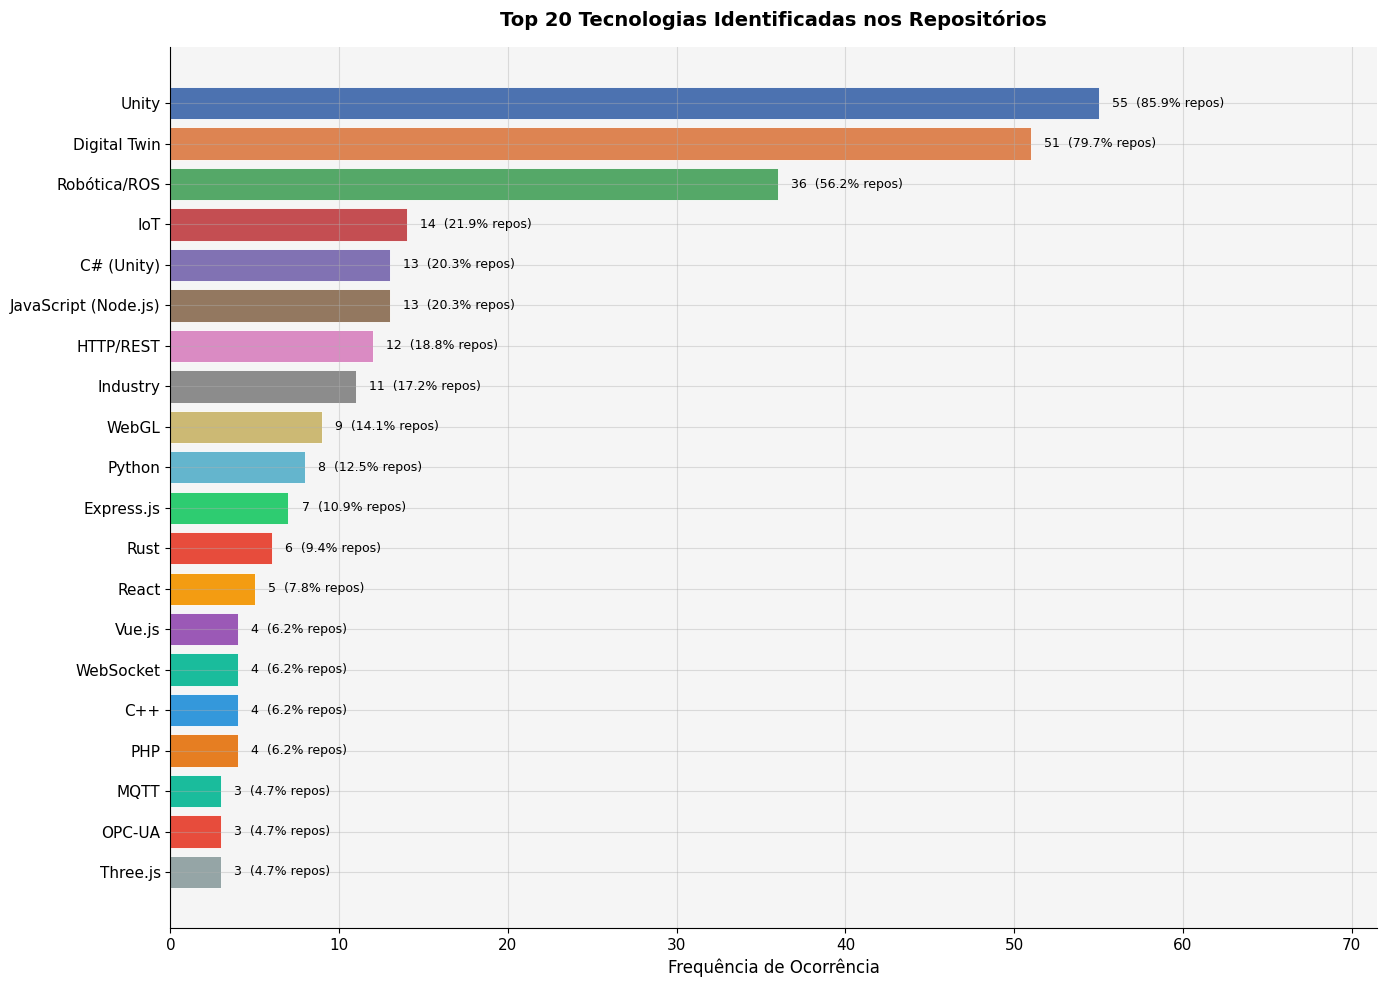

In [39]:
# gerando top 20 tecnologias atraves de um grafico de barras horizontais
# esse grafico nao categoriza, apenas exibe as top 20 por correspondencia em ordem descrescente

fig, ax = plt.subplots(figsize=(14, 10))
top20 = ranking_tech.head(20)
bars = ax.barh(range(len(top20)), top20['Frequência'],
                  color=CORES[:len(top20)], edgecolor='white', linewidth=0.6)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['Tecnologia'], fontsize=11)
ax.invert_yaxis()

ax.set_xlabel('Frequência de Ocorrência', fontsize=12)
ax.set_title('Top 20 Tecnologias Identificadas nos Repositórios',
             fontsize=14, fontweight='bold', pad=15)

for bar, freq, pct in zip(bars, top20['Frequência'], top20['% Repositórios']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'  {freq}  ({pct:.1f}% repos)', va='center', fontsize=9)
ax.set_xlim(0, top20['Frequência'].max() * 1.3)
plt.tight_layout()

# salvando
plt.savefig(PATH_OUT + 'viz_01_top20_tecnologias.png', dpi=150, bbox_inches='tight')

#exibindo
plt.show()


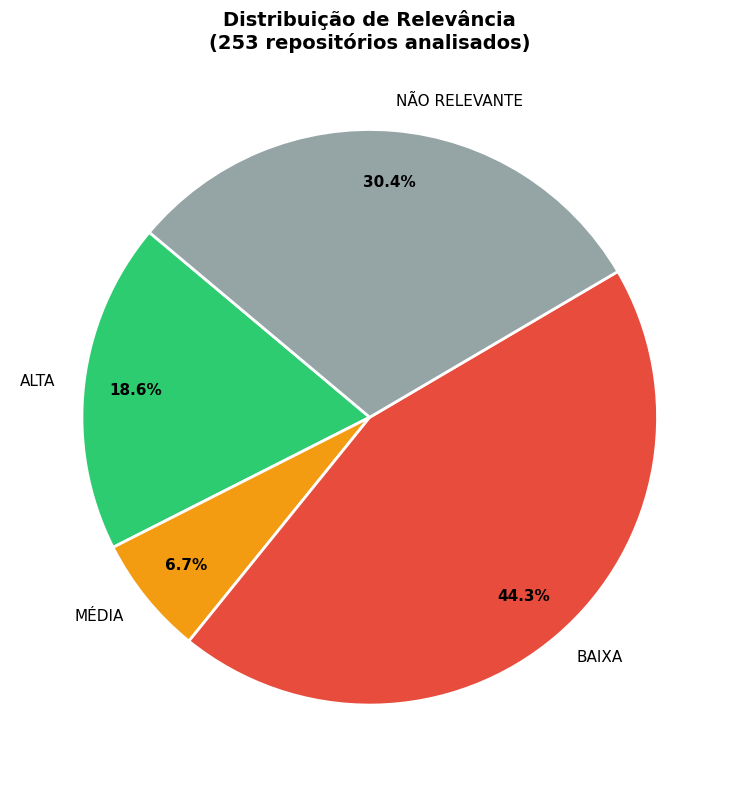

In [40]:
# geracao de grafico de pizza para visualizacao do aproveitamento da coleta

fig, ax      = plt.subplots(figsize=(8, 8))
ordem        = ['ALTA', 'MÉDIA', 'BAIXA', 'NÃO RELEVANTE']
contagem_rel = df['relevancia'].value_counts()

contagem_rel = contagem_rel.reindex([r for r in ordem if r in contagem_rel.index])

wedges, texts, autotexts = ax.pie(
    contagem_rel.values,
    labels=contagem_rel.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6'][:len(contagem_rel)],
    startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold')
ax.set_title(f'Distribuição de Relevância\n({len(df)} repositórios analisados)',
             fontsize=14, fontweight='bold')
plt.tight_layout()

#salvando na pasta
plt.savefig(PATH_OUT + 'viz_02_relevancia.png', dpi=150, bbox_inches='tight')

# exbibindo
plt.show()


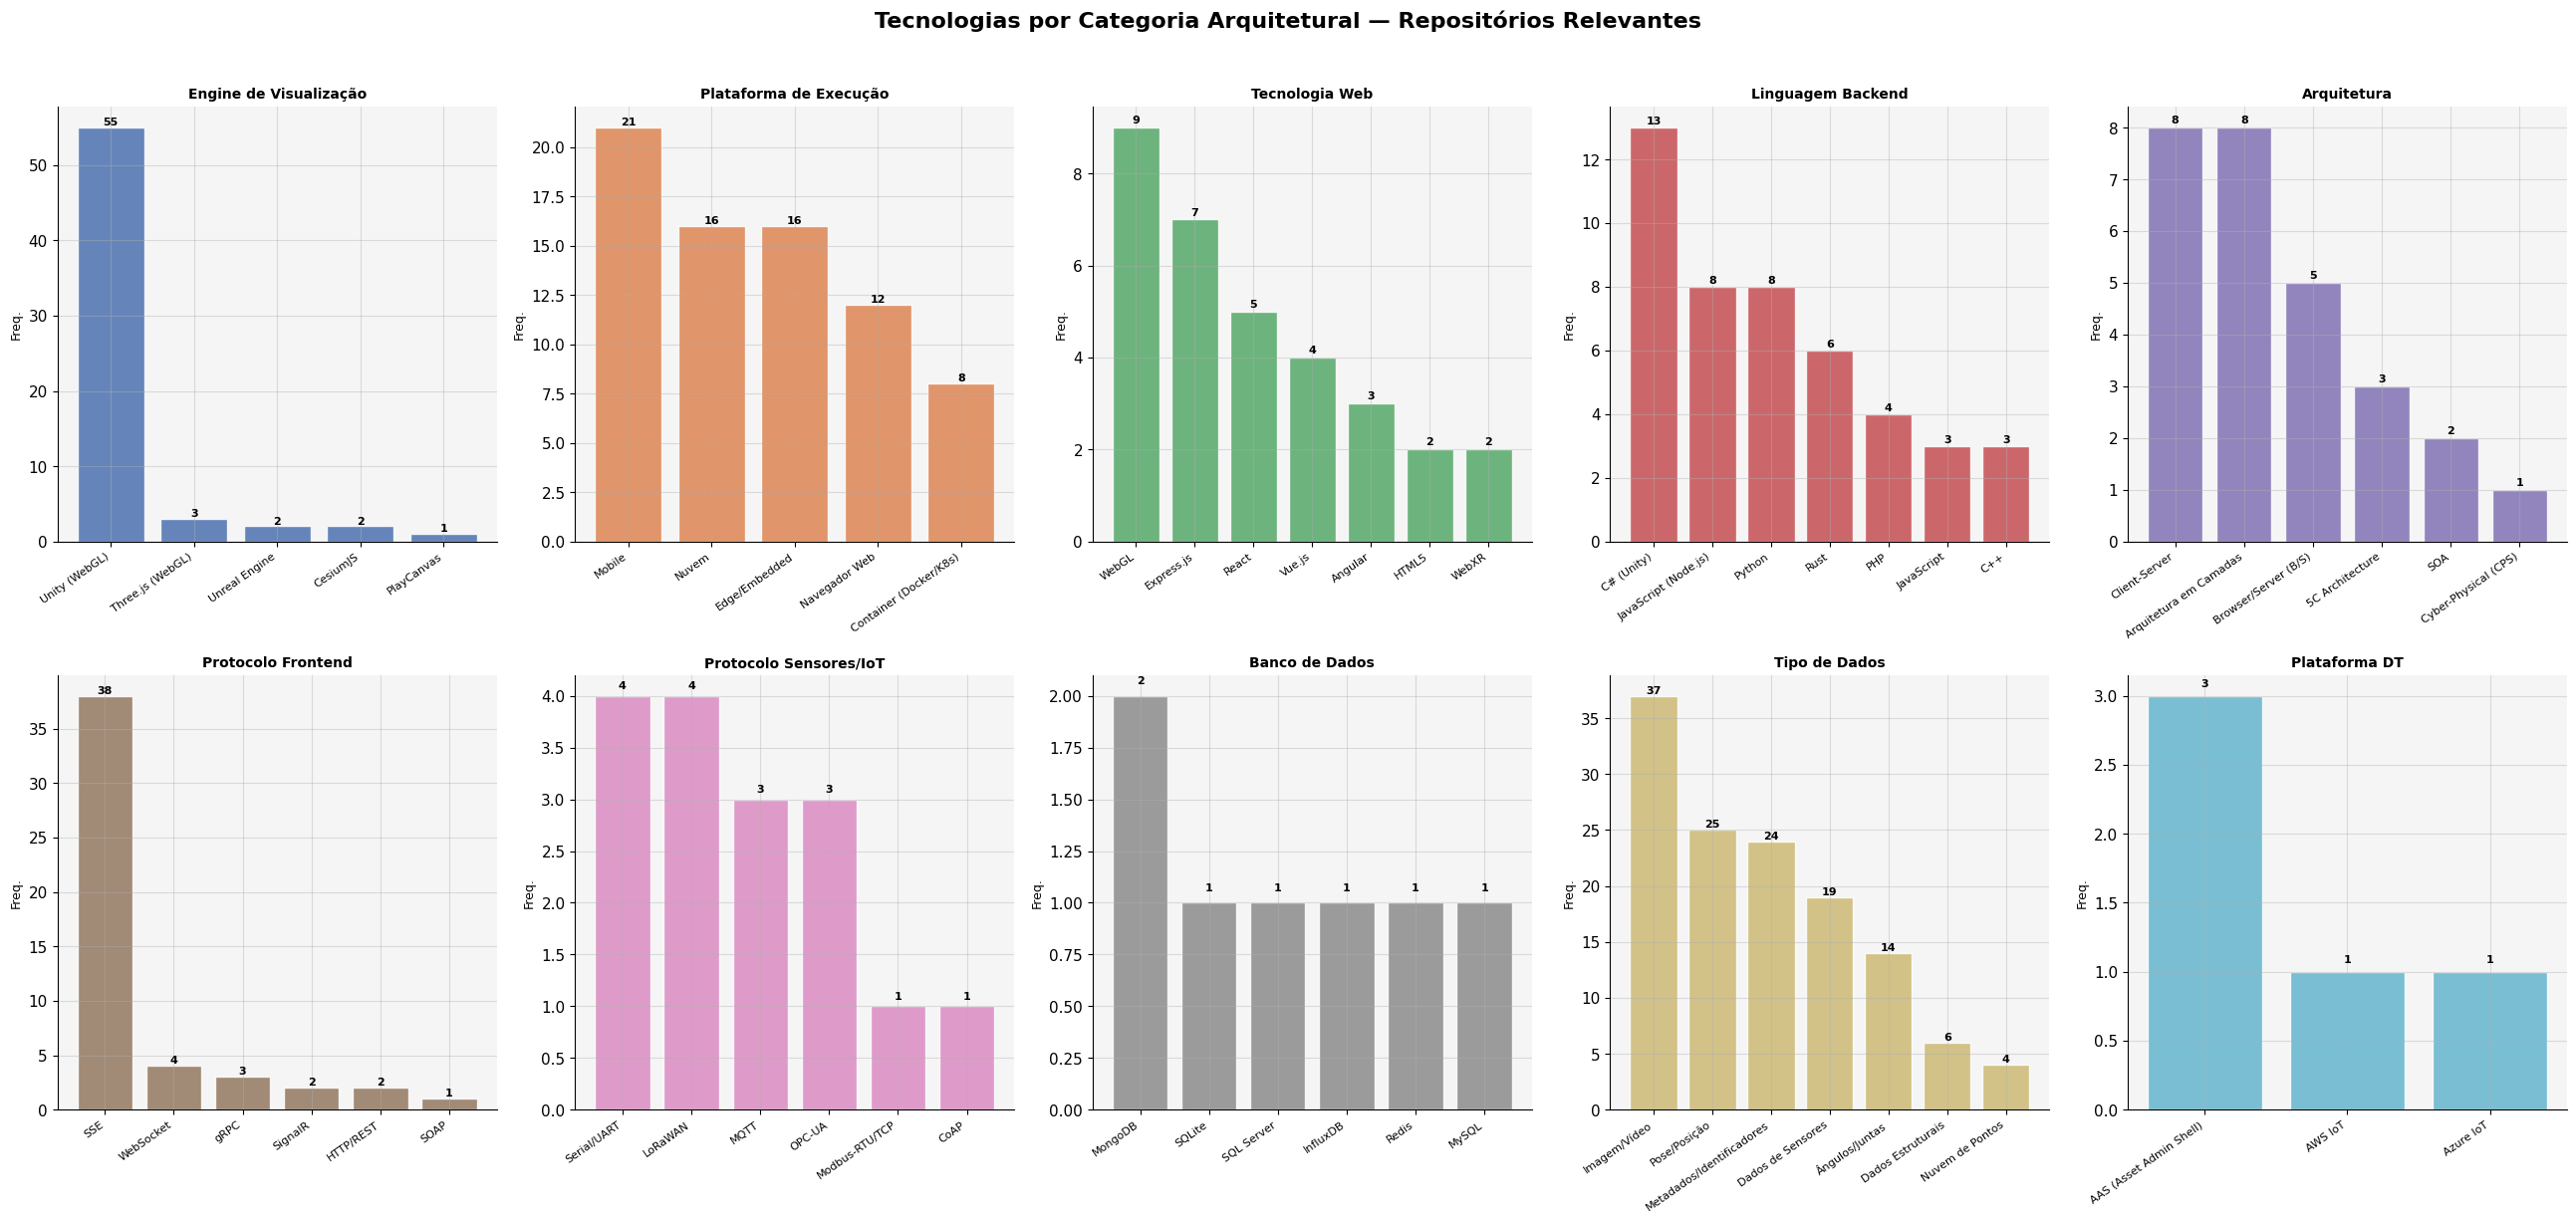

In [41]:
# visualizando categorias arquiteturais mencionadas de acordo com o dicionario criado e enriquecido

cat_contagem  = defaultdict(Counter)
categorias_labels = [
    'engine_visualizacao', 'plataforma_execucao', 'tecnologia_web',
    'linguagem_backend',   'arquitetura',          'protocolo_frontend',
    'protocolo_sensores',  'banco_dados',          'tipo_dados', 'plataforma_dt'
]
titulos_cat = [
    'Engine de Visualização', 'Plataforma de Execução', 'Tecnologia Web',
    'Linguagem Backend',      'Arquitetura',             'Protocolo Frontend',
    'Protocolo Sensores/IoT', 'Banco de Dados',          'Tipo de Dados', 'Plataforma DT'
]

for _, row in df_relevantes.iterrows():
    for cat, itens in row['categorias'].items():
        for item in itens:
            if item: cat_contagem[cat][item] += 1

fig, axes = plt.subplots(2, 5, figsize=(26, 12))
axes = axes.flatten()
fig.suptitle('Tecnologias por Categoria Arquitetural — Repositórios Relevantes',
             fontsize=16, fontweight='bold', y=1.02)

for i, (cat, titulo) in enumerate(zip(categorias_labels, titulos_cat)):
    ax    = axes[i]
    dados = cat_contagem.get(cat, Counter())
    if dados:
        top  = dict(sorted(dados.items(), key=lambda x: x[1], reverse=True)[:7])
        bars_cat = ax.bar(range(len(top)), list(top.values()),
                          color=CORES[i % len(CORES)], alpha=0.85, edgecolor='white')
        ax.set_xticks(range(len(top)))
        ax.set_xticklabels(list(top.keys()), rotation=35, ha='right', fontsize=8)
        ax.set_title(titulo, fontsize=10, fontweight='bold')
        ax.set_ylabel('Freq.', fontsize=9)
        for bar, val in zip(bars_cat, top.values()):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Sem dados', ha='center', va='center',
                fontsize=10, color='gray', style='italic')
        ax.set_title(titulo, fontsize=10, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
# visualizando e e salvando
plt.savefig(PATH_OUT + 'viz_03_categorias_expandidas.png', dpi=150, bbox_inches='tight')
plt.show()



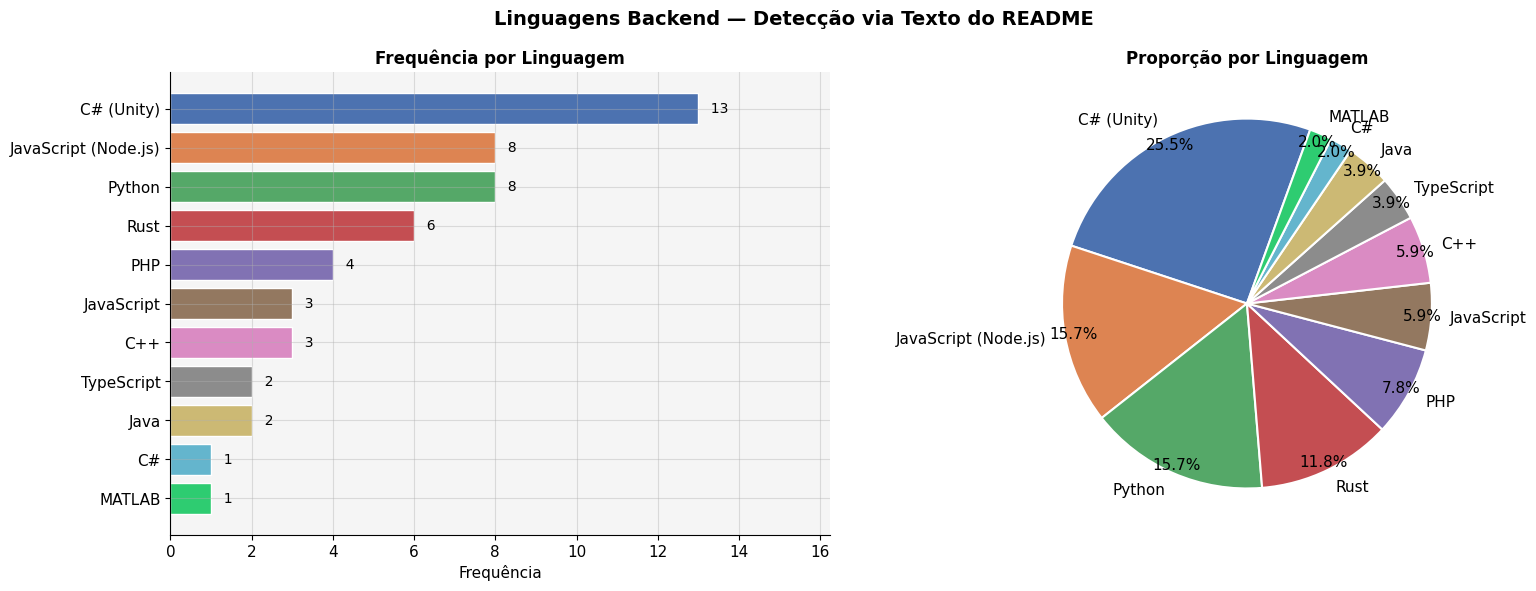

In [42]:
# visualizando as linguagens de backend

lang_data = cat_contagem.get('linguagem_backend', Counter())

if lang_data:
    lang_df = pd.DataFrame(lang_data.most_common(), columns=['Linguagem', 'Frequência'])

    fig, axes_l = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Linguagens Backend — Detecção via Texto do README',
                 fontsize=14, fontweight='bold')

    # Barras
    ax1 = axes_l[0]
    cores_l = CORES[:len(lang_df)]
    bars_l = ax1.barh(range(len(lang_df)), lang_df['Frequência'],
                      color=cores_l, edgecolor='white')
    ax1.set_yticks(range(len(lang_df)))
    ax1.set_yticklabels(lang_df['Linguagem'], fontsize=11)
    ax1.invert_yaxis()
    ax1.set_xlabel('Frequência', fontsize=11)
    ax1.set_title('Frequência por Linguagem', fontsize=12, fontweight='bold')
    for bar, val in zip(bars_l, lang_df['Frequência']):
        ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'  {val}', va='center', fontsize=10)
    ax1.set_xlim(0, lang_df['Frequência'].max() * 1.25)

    # Pizza
    ax2 = axes_l[1]
    ax2.pie(lang_df['Frequência'], labels=lang_df['Linguagem'],
            autopct='%1.1f%%', colors=cores_l,
            startangle=70, pctdistance=0.95,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax2.set_title('Proporção por Linguagem', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(PATH_OUT + 'viz_04_linguagens_backend.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('l8inguagem nao detectada')


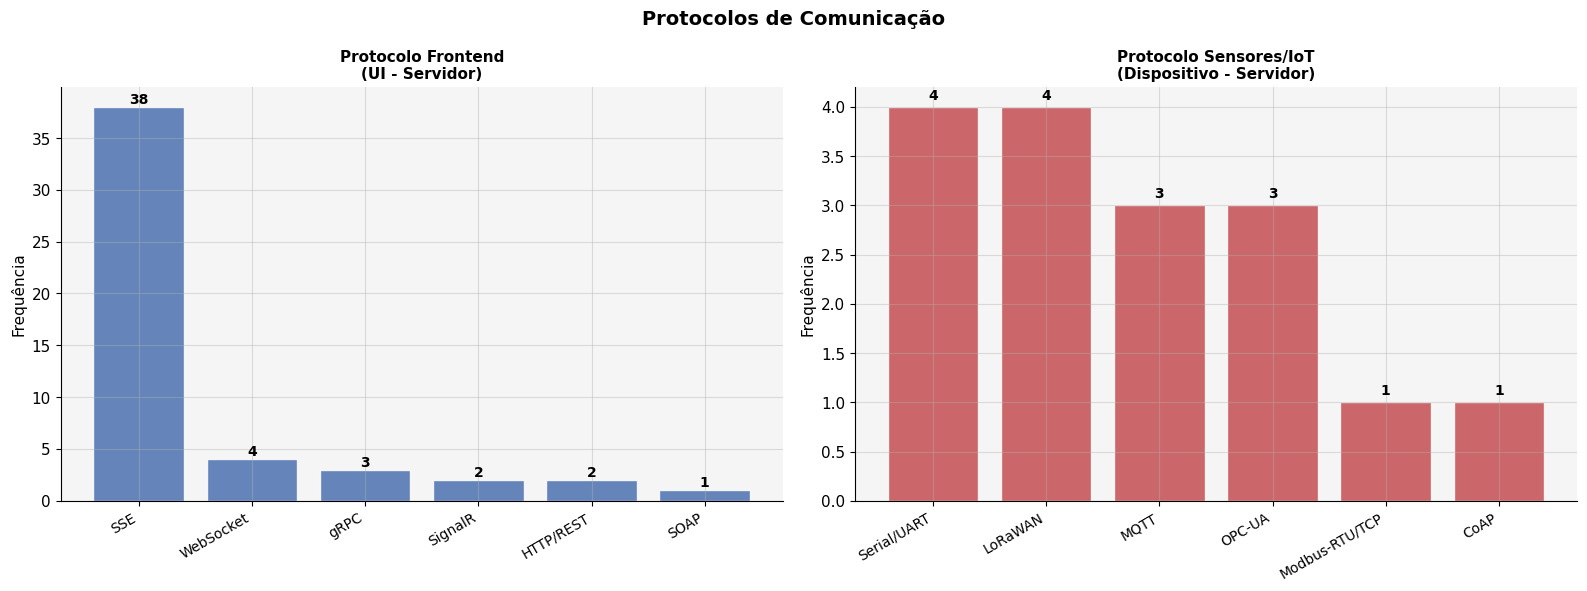

In [43]:
# visualizacao de graficos de protocolos usados no front e nos sensores

fig, axes_p = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Protocolos de Comunicação', fontsize=14, fontweight='bold')

for idx, (cat_key, titulo_p) in enumerate([
    ('protocolo_frontend', 'Protocolo Frontend\n(UI - Servidor)'),
    ('protocolo_sensores', 'Protocolo Sensores/IoT\n(Dispositivo - Servidor)')
]):
    ax_p  = axes_p[idx]
    dados_p = cat_contagem.get(cat_key, Counter())
    if dados_p:
        top_p = dict(sorted(dados_p.items(), key=lambda x: x[1], reverse=True)[:8])
        cor_p = CORES[idx * 3 % len(CORES)]
        bars_p = ax_p.bar(range(len(top_p)), list(top_p.values()),
                          color=cor_p, alpha=0.85, edgecolor='white')
        ax_p.set_xticks(range(len(top_p)))
        ax_p.set_xticklabels(list(top_p.keys()), rotation=30, ha='right', fontsize=10)
        ax_p.set_title(titulo_p, fontsize=11, fontweight='bold')
        ax_p.set_ylabel('Frequência')
        for bar_p, val_p in zip(bars_p, top_p.values()):
            ax_p.text(bar_p.get_x() + bar_p.get_width() / 2,
                      bar_p.get_height() + 0.05, str(val_p),
                      ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        ax_p.text(0.5, 0.5, 'Sem dados', ha='center', va='center',
                  fontsize=12, color='gray', style='italic')
        ax_p.set_title(titulo_p, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(PATH_OUT + 'viz_05_protocolos.png', dpi=150, bbox_inches='tight')
plt.show()

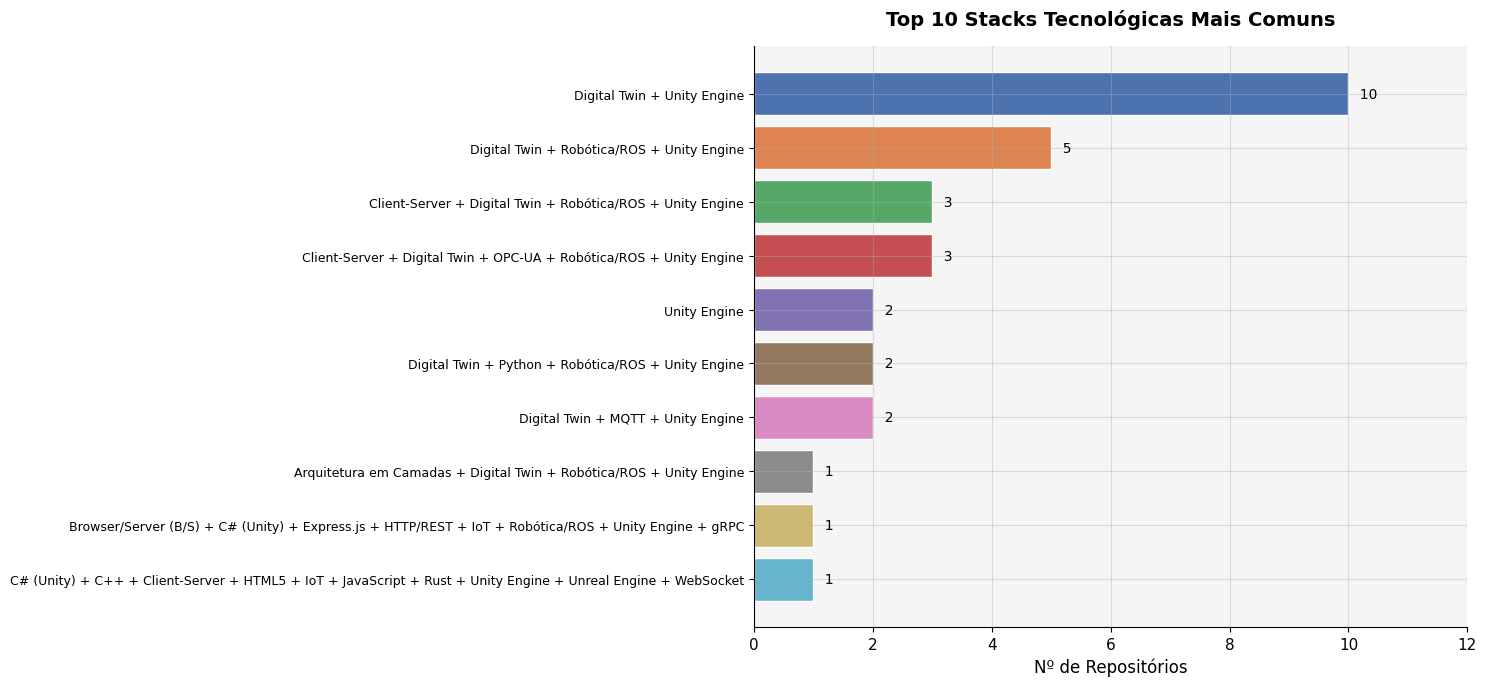

In [44]:
# visualizando top 10 stacks com maior correspondencia

stack_counts = df_relevantes['stack'].dropna().value_counts().head(10)

if len(stack_counts) > 0:
    fig, ax = plt.subplots(figsize=(15, 7))
    bars_s  = ax.barh(range(len(stack_counts)), stack_counts.values,
                      color=CORES[:len(stack_counts)], edgecolor='white')
    ax.set_yticks(range(len(stack_counts)))
    ax.set_yticklabels(stack_counts.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Nº de Repositórios', fontsize=12)
    ax.set_title('Top 10 Stacks Tecnológicas Mais Comuns',
                 fontsize=14, fontweight='bold', pad=15)
    for bar_s, val_s in zip(bars_s, stack_counts.values):
        ax.text(bar_s.get_width() + 0.05, bar_s.get_y() + bar_s.get_height() / 2,
                f'  {val_s}', va='center', fontsize=10)
    ax.set_xlim(0, stack_counts.values.max() * 1.2)
    plt.tight_layout()
    plt.savefig(PATH_OUT + 'viz_06_stacks.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nenhuma stack gerada')


In [27]:
!pip install wordcloud

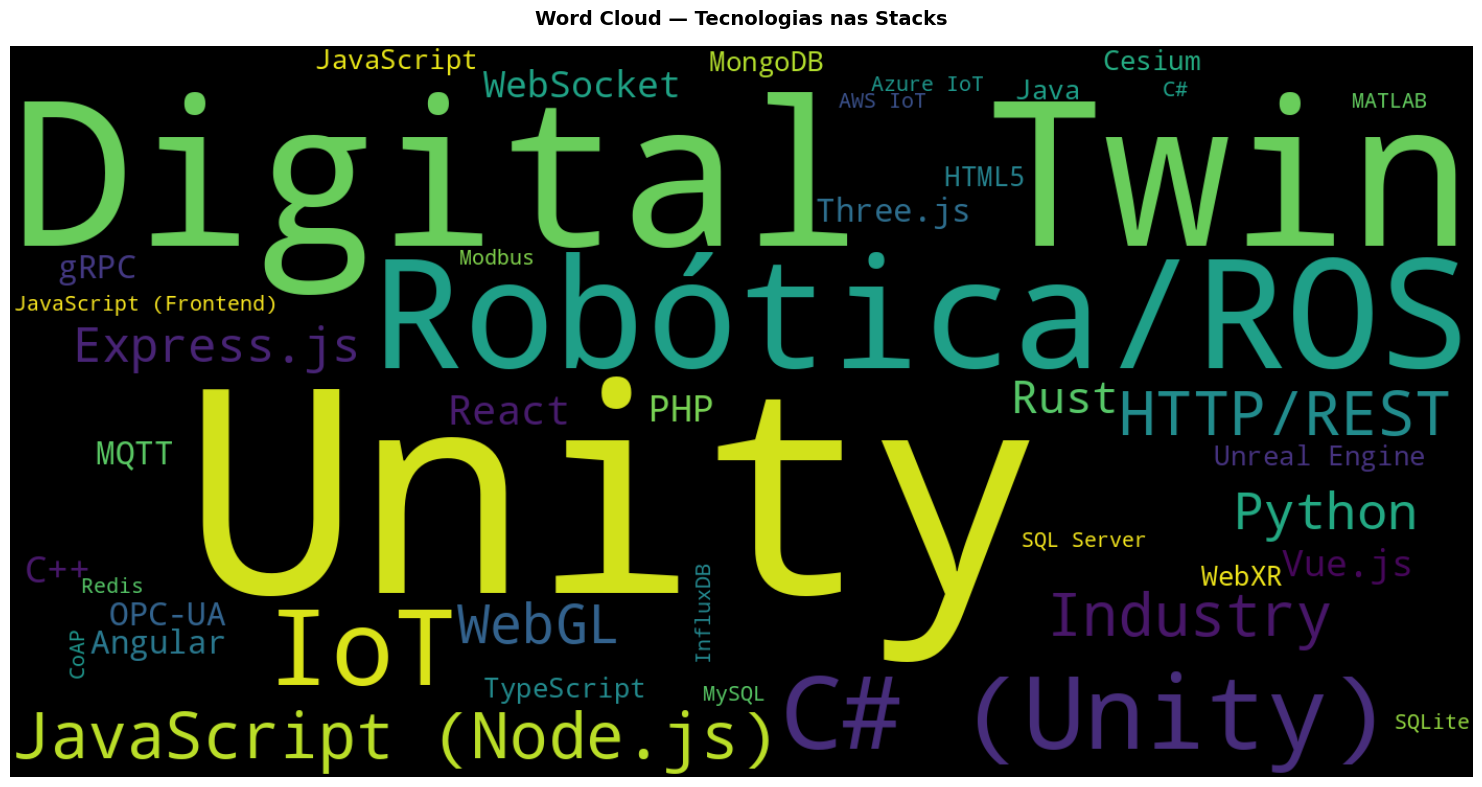

In [28]:
# gerando grafico de palavras e salvando na pasta atual

# from wordcloud import WordCloud

# Usando o ranking_tech para gerar a nuvem de palavras com termos

frequencies = dict(zip(ranking_tech['Tecnologia'], ranking_tech['Frequência']))

wc = WordCloud(
    width=1400, height=700,
    background_color='black',
    colormap='viridis',
    max_words=100,
    collocations=False
).generate_from_frequencies(frequencies)

fig, ax_wc = plt.subplots(figsize=(16, 8))
ax_wc.imshow(wc, interpolation='bilinear')
ax_wc.axis('off')
ax_wc.set_title('Word Cloud — Tecnologias nas Stacks',
                fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(PATH_OUT + 'viz_08_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
import pandas as pd

# Filtrar os 10 repositórios mais relevantes
top_30_relevantes = df_relevantes.sort_values(by='score', ascending=False).head(50)

# Selecionar as colunas desejadas
df_final_xlsx = top_30_relevantes[['Nome do Repositório', 'URL', 'score', 'stack']]

# Definir o nome do arquivo e o caminho completo
nome_arquivo = 'top_30_repositorios_relevantes.xlsx'
caminho_completo = PATH_OUT + nome_arquivo

# Salvar o DataFrame para um arquivo XLSX
df_final_xlsx.to_excel(caminho_completo, index=False)

print(f'Planilha salva em: {caminho_completo}')
display(df_final_xlsx)

Planilha salva em: /content/drive/MyDrive/pesquisa_gemeo_digital_web/top_30_repositorios_relevantes.xlsx


,Nome do Repositório,URL,score,stack
190,BaR-Motion-Workshop,https://github.com/rparak/BaR-Motion-Workshop,8,Client-Server + Digital Twin + OPC-UA + Robóti...
171,Unity3D_Robotics_Sorting_Machine,https://github.com/rparak/Unity3D_Robotics_Sor...,8,Client-Server + Digital Twin + OPC-UA + Robóti...
214,Unity3D_Robotics_ACOPOStrak,https://github.com/rparak/Unity3D_Robotics_ACO...,8,Client-Server + Digital Twin + OPC-UA + Robóti...
121,Digital-Twin-of-Anthropomorphic-Robotic-Arm,https://github.com/yudhisteer/Digital-Twin-of-...,7,5C Architecture + Arquitetura em Camadas + Dig...
237,Gemini,https://github.com/ManuelPozor/Gemini,7,Digital Twin + MQTT + Unity Engine
235,Azure-digitaltwins-windfarm,https://github.com/Ashref-dev/Azure-digitaltwi...,7,Azure IoT + Digital Twin + IoT + Robótica/ROS ...
226,Awesome-AECO,https://github.com/osama-ata/Awesome-AECO,7,Arquitetura em Camadas + C++ + CesiumJS + Digi...
185,GEMINI,https://github.com/WEKIT-ECS/GEMINI,7,Digital Twin + MQTT + Unity Engine
187,Digital-Twin-of-a-Traffic-Scene-Using-RSU-and-...,https://github.com/rzninvo/Digital-Twin-of-a-T...,6,5C Architecture + Arquitetura em Camadas + Dig...
141,Aeolus-Ocean,https://github.com/aavek/Aeolus-Ocean,6,Arquitetura em Camadas + Digital Twin + HTTP/R...


In [47]:
#gerando um relatorio final na output

print('=' * 60)
print('RESUMO DO PIPELINE')
print('=' * 60)
print(f'Repositórios analisados         : {len(df)}')
print(f'Repositórios relevantes (≥3)    : {len(df_relevantes)}')
print(f'Stacks preenchidas              : {df_relevantes["stack"].notna().sum()}')
print(f'Stacks vazias                   : {df_relevantes["stack"].isna().sum()}')
print(f'Tecnologias distintas           : {len(ranking_tech)}')
print(f'Categorias arquiteturais        : 10')
print(f'Gráficos salvos em              : {PATH_OUT}')
print('=' * 60)

print('\nTOP 5 TECNOLOGIAS GERAIS:')
print(ranking_tech.head(5)[['Tecnologia','Frequência','% Repositórios']].to_string(index=False))

print('\nLINGUAGENS BACKEND DETECTADAS:')
lang_d = cat_contagem.get('linguagem_backend', Counter())
if lang_d:
    for lang, freq in lang_d.most_common():
        print(f'  {lang:<30} {freq}')
else:
    print('sem readme')

print('\nPROTOCOLOS DE SENSORES:')
for proto, freq in cat_contagem.get('protocolo_sensores', Counter()).most_common():
    print(f'  {proto:<30} {freq}')

print('\nTOP STACKS:')
print(df_relevantes['stack'].dropna().value_counts().head(5).to_string())


RESUMO DO PIPELINE
Repositórios analisados         : 253
Repositórios relevantes (≥3)    : 64
Stacks preenchidas              : 64
Stacks vazias                   : 0
Tecnologias distintas           : 42
Categorias arquiteturais        : 10
Gráficos salvos em              : /content/drive/MyDrive/pesquisa_gemeo_digital_web/

TOP 5 TECNOLOGIAS GERAIS:
  Tecnologia  Frequência  % Repositórios
       Unity          55            85.9
Digital Twin          51            79.7
Robótica/ROS          36            56.2
         IoT          14            21.9
  C# (Unity)          13            20.3

LINGUAGENS BACKEND DETECTADAS:
  C# (Unity)                     13
  JavaScript (Node.js)           8
  Python                         8
  Rust                           6
  PHP                            4
  JavaScript                     3
  C++                            3
  TypeScript                     2
  Java                           2
  C#                             1
  MATLAB          